# Verify video pipeline

Confirm a raw LRS3-trainval frame, after the grayscale transform the
frozen appearance encoder expects (see CLAUDE.md's "Precisely where and
why grayscale happens" note -- grayscale is applied at data-LOADING time,
not baked into the saved crop files), ends up the same shape/format as
lrs3-test's native, already-preprocessed frames.

**What "looks right" means:**
- After grayscale + resize/crop, a trainval frame's tensor shape matches
  lrs3-test's native `(96, 96)` frame shape exactly.
- dtype and value range (e.g. `uint8` 0-255 vs `float32` 0-1) are
  consistent between the two, or the mismatch is understood and
  intentional.
- The two frames look like reasonably consistent mouth crops side by
  side -- similar framing/scale, not wildly different zoom levels or
  face positions. lrs3-test went through an unknown external
  preprocessing pipeline, so this is a one-time eyeball check, not
  something to assume matches without looking.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as T
from datasets import load_dataset

/ROIHU_TYKKY_5326GQe/miniforge/envs/env1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [2]:
# TODO: fill in a real path from notebook 01's lrs3_trainval manifest video_path column
import random, pandas as pd

DATASET_ROOT = Path("your_path_to_dataset")
LRS3_TEST_PARQUET_DIR = DATASET_ROOT / "lrs3" / "test-mattymchen" / "data"

lrs3_trainval_manifest = pd.read_csv("lrs3_trainval_manifest.csv")
lrs3_sample = lrs3_trainval_manifest.iloc[int(random.uniform(0, len(lrs3_trainval_manifest)))]
SAMPLE_TRAINVAL_VIDEO_PATH = Path(lrs3_sample["video_path"])

## Load one raw LRS3-trainval frame

In [3]:
from scripts.extract_landmarks_grid import _read_video_via_torchcodec
video_frames, _audio, _info = _read_video_via_torchcodec(str(SAMPLE_TRAINVAL_VIDEO_PATH), pts_unit="sec")
raw_frame = video_frames[0]  # (H, W, C), uint8, RGB
print(f"raw frame shape: {tuple(raw_frame.shape)}, dtype: {raw_frame.dtype}")

raw frame shape: (224, 224, 3), dtype: torch.uint8


## Apply the grayscale + resize/crop transform

TODO: this should match whatever `fusion_avsr`'s data-loading transform
pipeline eventually implements for the appearance encoder (mirroring
auto-AVSR's `transforms.py`) -- I'll fill in the real crop/resize logic once
that exists; the `Grayscale()` + `Resize((96, 96))` below is a
placeholder standing in for it.

In [5]:
transform = T.Compose([
    T.ToPILImage(),
    T.Grayscale(),
    T.Resize((96, 96)),  # TODO: I'll replace with the real mouth-crop logic, not a naive resize
    T.PILToTensor(),
])

# torchvision frames are (H, W, C); ToPILImage expects (C, H, W)
processed_frame = transform(raw_frame.permute(2, 0, 1))
print(f"processed frame shape: {tuple(processed_frame.shape)}, dtype: {processed_frame.dtype}")

processed frame shape: (1, 96, 96), dtype: torch.uint8


## Load one lrs3-test frame for comparison

In [6]:
lrs3_test = load_dataset("parquet", data_dir=str(LRS3_TEST_PARQUET_DIR))["train"]

lrs3_test_example = lrs3_test[0]
lrs3_test_frame = lrs3_test_example["video"][0]  # first frame, native (96, 96)
print(f"lrs3_test frame shape: {len(lrs3_test_frame)}x{len(lrs3_test_frame[0])}")

2026-09-20 13:00:05 INFO httpx: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"


lrs3_test frame shape: 96x96


## Visual side-by-side

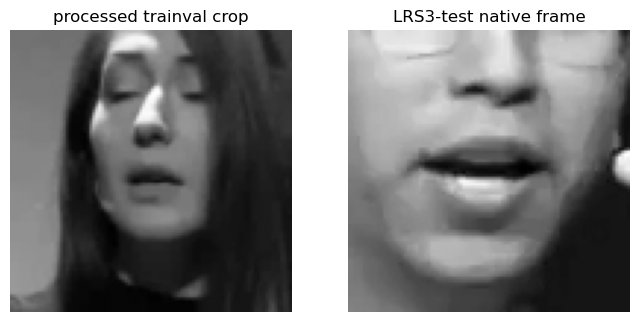

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(processed_frame.squeeze(0), cmap="gray")
axes[0].set_title("processed trainval crop")
axes[1].imshow(lrs3_test_frame, cmap="gray")
axes[1].set_title("LRS3-test native frame")
for ax in axes:
    ax.axis("off")
plt.show()

## TODO checklist

- [ ] `processed_frame.shape[-2:] == (96, 96)`, matching lrs3-test's
      native frame shape.
- [ ] Both frames are single-channel (grayscale).
- [ ] Crop framing/scale look reasonably consistent side by side (not
      wildly different zoom/position) -- if they diverge visibly, that's
      a provenance difference (lrs3-test's unknown external
      pipeline), not necessarily a bug in our own pipeline.